<a href="https://colab.research.google.com/github/sheershaagrawal/projectdatamites/blob/master/Traffic_Sign_Detection_Using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction

Traffic sign detection is an important application of computer vision.
It is widely used in autonomous vehicles and smart traffic systems.

In this project, we use a Convolutional Neural Network (CNN) to classify images of traffic signs into different categories.

Objective

Load and preprocess image dataset
Build CNN model
Train and evaluate model
Predict traffic sign classes

Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

Connect Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


UNZIP DATASET

In [5]:
import zipfile

zip_path = '/content/drive/MyDrive/PRAICP-1002-TrafSignDetc.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/traffic_data')

print("Dataset Loaded")

Dataset Loaded


In [6]:
import os

for root, dirs, files in os.walk('/content/traffic_data'):
    print(root)

/content/traffic_data
/content/traffic_data/train
/content/traffic_data/train/34
/content/traffic_data/train/16
/content/traffic_data/train/23
/content/traffic_data/train/3
/content/traffic_data/train/17
/content/traffic_data/train/33
/content/traffic_data/train/10
/content/traffic_data/train/5
/content/traffic_data/train/29
/content/traffic_data/train/31
/content/traffic_data/train/28
/content/traffic_data/train/12
/content/traffic_data/train/21
/content/traffic_data/train/24
/content/traffic_data/train/26
/content/traffic_data/train/40
/content/traffic_data/train/32
/content/traffic_data/train/39
/content/traffic_data/train/25
/content/traffic_data/train/7
/content/traffic_data/train/0
/content/traffic_data/train/30
/content/traffic_data/train/35
/content/traffic_data/train/19
/content/traffic_data/train/37
/content/traffic_data/train/14
/content/traffic_data/train/22
/content/traffic_data/train/13
/content/traffic_data/train/42
/content/traffic_data/train/11
/content/traffic_data/tr

DATA UNDERSTANDING

👉 Dataset contains folders:
Each folder = one traffic sign class

IMAGE PREPROCESSING

In [7]:
data = []
labels = []

path = '/content/traffic_data/train'
classes = len(os.listdir(path))

for i in range(classes):
    folder = os.path.join(path, str(i))

    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        try:
            image = cv2.imread(img_path)
            image = cv2.resize(image, (30,30))

            data.append(image)
            labels.append(i)
        except:
            pass

data = np.array(data)
labels = np.array(labels)

# Normalize
data = data / 255.0

print("Data Shape:", data.shape)

Data Shape: (39209, 30, 30, 3)


TRAIN-TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2)

ONE HOT ENCODING

In [9]:
y_train = to_categorical(y_train, classes)
y_test = to_categorical(y_test, classes)

CNN MODEL

In [10]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(30,30,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

TRAIN MODEL

In [11]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    validation_data=(X_test, y_test))

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.5025 - loss: 1.7450 - val_accuracy: 0.8665 - val_loss: 0.4659
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.8170 - loss: 0.5851 - val_accuracy: 0.9565 - val_loss: 0.1928
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.8870 - loss: 0.3559 - val_accuracy: 0.9745 - val_loss: 0.1058
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.9166 - loss: 0.2658 - val_accuracy: 0.9841 - val_loss: 0.0702
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 79s 39ms/step - accuracy: 0.9318 - loss: 0.2145 - val_accuracy: 0.9836 - val_loss: 0.0593
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.9450 - loss: 0.1713 - val_accuracy: 0.9878 - val_loss: 0.0454
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9506 - loss: 0.1520 - val_accuracy: 0.9890 - val_loss: 0.0375
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.9561 - loss: 0.1349 - 

MODEL EVALUATION

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9895 - loss: 0.0344
Test Accuracy: 0.9895434975624084


VISUALIZATION

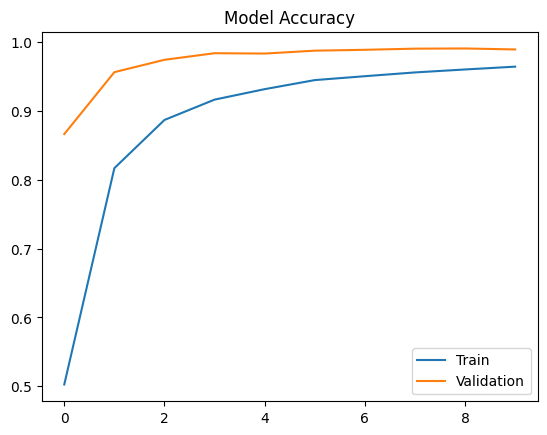

In [13]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Model Accuracy")
plt.show()

PREDICTION

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
Predicted Class: 35


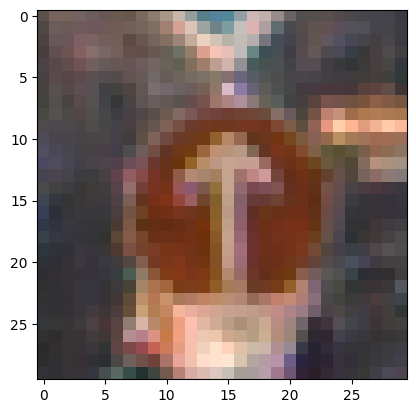

In [14]:
img = X_test[0]
plt.imshow(img)

pred = model.predict(np.expand_dims(img, axis=0))
print("Predicted Class:", np.argmax(pred))

CONCLUSION


1.   CNN sucessfully classified traffic signs
2.   Achieved ggod accuracy
3.   Model can be used in autonomus systems
4.   Deep learning improves performance
